In [174]:

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [175]:
all_data  = pd.read_csv("new_nifty_top15_prices_2010_2024.csv",index_col= "Date" ,parse_dates = ["Date"]).dropna()
all_data

,AXISBANK.NS,BAJFINANCE.NS,BHARTIARTL.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,M&M.NS,RELIANCE.NS,SBIN.NS,TCS.NS,^NSEI
Date,,,,,,,,,,,,,,,,
2010-01-04,180.627899,3.028105,270.075684,62.352825,73.725151,197.109497,133.353134,217.472565,48.353577,40.643486,597.963867,237.022522,217.587051,185.358688,259.259125,5232.200195
2010-01-05,184.396698,3.007806,274.352753,63.755787,73.790016,196.476517,134.618912,218.200943,48.830139,41.046024,599.024597,241.385986,216.615967,185.427460,259.328064,5277.899902
2010-01-06,181.301559,3.051052,271.445984,61.831932,73.839699,197.593491,135.649689,215.017014,48.944515,41.544872,592.395752,247.175949,220.115952,186.539856,253.464539,5281.799805
2010-01-07,182.585129,3.032518,273.563782,60.512951,74.032036,197.183914,134.368774,210.184967,48.792023,42.011608,589.549744,242.466354,223.767700,185.496201,246.410782,5263.100098
2010-01-08,184.970200,3.087678,269.951141,59.101585,74.129272,198.040314,132.481491,205.119812,48.896866,41.752316,593.279724,242.487350,223.181015,184.942062,241.375076,5244.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,1078.228516,682.458862,1573.743652,1785.912354,874.034241,2296.506836,1286.870483,1829.401367,420.904694,348.667999,3571.972412,2886.112793,1211.834717,790.733276,3893.971436,23753.449219
2024-12-24,1077.978760,676.644775,1570.768555,1780.234375,872.626892,2293.217529,1287.317017,1814.903442,424.632233,349.407135,3571.236572,2905.358154,1212.280884,781.970276,3913.824463,23727.650391
2024-12-26,1075.780518,677.395142,1586.239258,1783.800903,869.059875,2290.468262,1287.416138,1813.334839,423.300964,350.156281,3561.179688,2951.933838,1206.133911,782.355469,3904.085205,23750.199219


In [176]:
all_data_pct = np.log(all_data/all_data.shift()).dropna()
all_data_pct

,AXISBANK.NS,BAJFINANCE.NS,BHARTIARTL.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,M&M.NS,RELIANCE.NS,SBIN.NS,TCS.NS,^NSEI
Date,,,,,,,,,,,,,,,,
2010-01-05,0.020650,-0.006726,0.015712,0.022251,0.000879,-0.003216,0.009447,0.003344,0.009808,0.009855,0.001772,0.018242,-0.004473,0.000371,0.000266,0.008696
2010-01-06,-0.016928,0.014276,-0.010652,-0.030640,0.000673,0.005669,0.007628,-0.014699,0.002340,0.012080,-0.011128,0.023703,0.016028,0.005981,-0.022870,0.000739
2010-01-07,0.007055,-0.006093,0.007772,-0.021563,0.002601,-0.002075,-0.009488,-0.022729,-0.003120,0.011172,-0.004816,-0.019237,0.016454,-0.005611,-0.028224,-0.003547
2010-01-08,0.012978,0.018026,-0.013294,-0.023600,0.001313,0.004334,-0.014145,-0.024394,0.002146,-0.006191,0.006307,0.000087,-0.002625,-0.002992,-0.020648,-0.003493
2010-01-11,0.032394,0.024982,0.011927,0.009901,-0.004031,0.000564,-0.005220,0.010275,0.000390,0.003837,-0.000507,0.002851,-0.019821,-0.008280,0.020368,0.000886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,0.006788,0.002690,0.005561,-0.004378,0.016515,0.002140,0.006499,0.001118,0.020450,0.001032,0.002930,0.001015,0.014006,0.011206,-0.002882,0.007011
2024-12-24,-0.000232,-0.008556,-0.001892,-0.003184,-0.001611,-0.001433,0.000347,-0.007957,0.008817,0.002118,-0.000206,0.006646,0.000368,-0.011144,0.005085,-0.001087
2024-12-26,-0.002041,0.001108,0.009801,0.002001,-0.004096,-0.001200,0.000077,-0.000865,-0.003140,0.002142,-0.002820,0.015904,-0.005083,0.000492,-0.002492,0.000950


In [177]:
X = all_data_pct.drop(columns=["^NSEI"])

In [178]:
Y = all_data_pct["^NSEI"]

In [179]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature shape:", X_scaled.shape)
print("\nFirst 3 scaled rows:")
print(X_scaled[:3])

Scaled feature shape: (3678, 15)

First 3 scaled rows:
[[ 9.31420056e-01 -3.67123657e-01  7.88543406e-01  1.21068839e+00
   1.43202731e-02 -2.64323502e-01  4.39843766e-01  1.60214999e-01
   5.92816255e-01  5.31993353e-01  7.16616511e-02  9.21275978e-01
  -2.85776985e-01 -5.94350999e-04 -3.01417455e-02]
 [-8.04144352e-01  5.73141570e-01 -5.76177749e-01 -1.79067487e+00
   2.89985198e-04  3.40274318e-01  3.49231670e-01 -8.84409566e-01
   1.12528113e-01  6.59642683e-01 -6.44397281e-01  1.20788840e+00
   9.00873405e-01  2.69001382e-01 -1.51136116e+00]
 [ 3.03503130e-01 -3.38785907e-01  3.77489606e-01 -1.27556126e+00
   1.31392522e-01 -1.86650975e-01 -5.03212892e-01 -1.34931836e+00
  -2.38626838e-01  6.07528731e-01 -2.94033666e-01 -1.04575289e+00
   9.25507115e-01 -2.88030329e-01 -1.85413508e+00]]


In [180]:
inertia_list = []
silhouette_list = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, labels))

results_k = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertia_list,
    "silhouette": silhouette_list
})

print(results_k)

    k       inertia  silhouette
0   2  45143.147488    0.157701
1   3  41276.789570    0.134419
2   4  39312.026919    0.088698
3   5  37689.870156    0.076051
4   6  36529.081314    0.075777
5   7  35573.262927    0.067976
6   8  34738.688760    0.058995
7   9  34042.377099    0.053542
8  10  33483.052899    0.053316


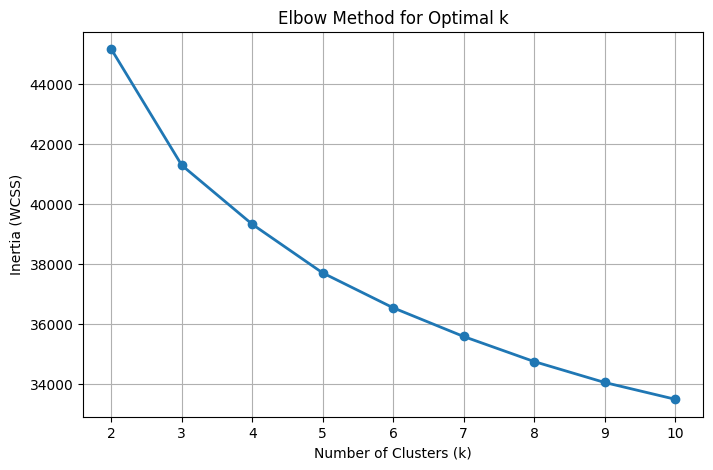

In [181]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertia_list,
    marker='o',
    linewidth=2
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Optimal k")
plt.xticks(k_values)
plt.grid(True)

plt.show()

In [182]:
from kneed import KneeLocator

knee = KneeLocator(
    k_values,
    inertia_list,
    curve='convex',
    direction='decreasing'
)

print("Optimal k =", knee.elbow)

Optimal k = 5


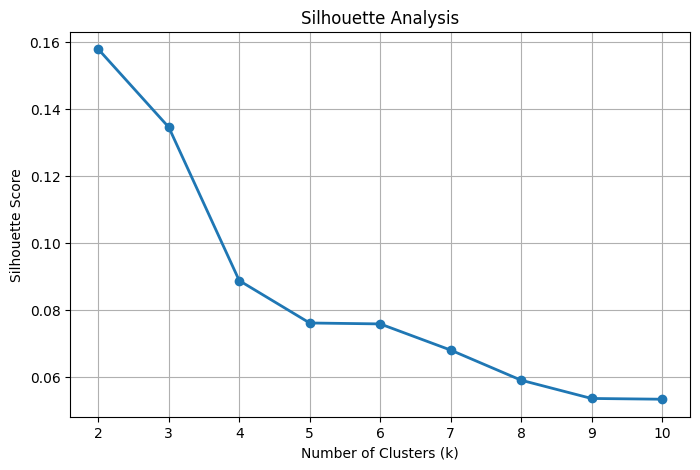

In [183]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_list,
    marker='o',
    linewidth=2
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.xticks(k_values)
plt.grid(True)

plt.show()


# Silhouette Score	Quality
# > 0.70	Excellent
# 0.50 – 0.70	Good
# 0.25 – 0.50	Weak
# < 0.25	Poor

In [184]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

all_data_pct["Cluster"] = clusters

print("Cluster counts:")
print(all_data_pct["Cluster"].value_counts())

print("\nFirst 10 rows with clusters:")
print(all_data_pct[["^NSEI", "Cluster"]].head(10))

Cluster counts:
4    1030
3    1024
1     991
2     427
0     206
Name: Cluster, dtype: int64

First 10 rows with clusters:
               ^NSEI  Cluster
Date                         
2010-01-05  0.008696        3
2010-01-06  0.000739        1
2010-01-07 -0.003547        1
2010-01-08 -0.003493        1
2010-01-11  0.000886        3
2010-01-12 -0.007457        3
2010-01-13  0.004510        3
2010-01-14  0.004946        1
2010-01-15 -0.001465        3
2010-01-18  0.004303        2


In [185]:
# Step 7: Compare clusters with HDFCBANK behavior
# Why this step comes after Step 6:
# We already created cluster labels.
# Now we want to understand what each cluster means.

cluster_summary = all_data_pct.groupby("Cluster")["^NSEI"].agg(["count", "mean", "median", "std", "min", "max"])
print(cluster_summary)

print("\nCluster-wise Target Mean:")
print(all_data_pct.groupby("Cluster")["^NSEI"].mean())

print("\nCluster-wise Target Median:")
print(all_data_pct.groupby("Cluster")["^NSEI"].median())

         count      mean    median       std       min       max
Cluster                                                         
0          206 -0.023056 -0.019977  0.013295 -0.139038 -0.008311
1          991  0.001475  0.001481  0.004237 -0.014818  0.013511
2          427  0.016347  0.015070  0.008236  0.002295  0.084003
3         1024  0.004585  0.004388  0.004398 -0.008638  0.024762
4         1030 -0.006679 -0.006242  0.004269 -0.022903  0.007090

Cluster-wise Target Mean:
Cluster
0   -0.023056
1    0.001475
2    0.016347
3    0.004585
4   -0.006679
Name: ^NSEI, dtype: float64

Cluster-wise Target Median:
Cluster
0   -0.019977
1    0.001481
2    0.015070
3    0.004388
4   -0.006242
Name: ^NSEI, dtype: float64


In [186]:
if "Target" in all_data_pct.columns:
    cluster_target_summary = all_data_pct.groupby("Cluster")["Target"].agg(["count", "mean", "median", "std"])
    print(cluster_target_summary)

    print("\nCluster-wise target mean:")
    print(all_data_pct.groupby("Cluster")["Target"].mean())

    print("\nCluster-wise target median:")
    print(all_data_pct.groupby("Cluster")["Target"].median())
else:
    print("Target column not found in ALLData.")

Target column not found in ALLData.


In [187]:
print("Columns in ALLData:")
print(all_data_pct.columns.tolist())

if "Direction" not in all_data_pct.columns:
    all_data_pct["Direction"] = (all_data_pct["^NSEI"].shift(-1) > 0).astype(int)

print("\nDirection distribution:")
print(all_data_pct["Direction"].value_counts(dropna=False))

print("\nFirst 10 rows with Direction:")
print(all_data_pct[["^NSEI", "Direction"]].head(10))

Columns in ALLData:
['AXISBANK.NS', 'BAJFINANCE.NS', 'BHARTIARTL.NS', 'HCLTECH.NS', 'HDFCBANK.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'INFY.NS', 'ITC.NS', 'KOTAKBANK.NS', 'LT.NS', 'M&M.NS', 'RELIANCE.NS', 'SBIN.NS', 'TCS.NS', '^NSEI', 'Cluster']

Direction distribution:
1    1964
0    1714
Name: Direction, dtype: int64

First 10 rows with Direction:
               ^NSEI  Direction
Date                           
2010-01-05  0.008696          1
2010-01-06  0.000739          0
2010-01-07 -0.003547          0
2010-01-08 -0.003493          1
2010-01-11  0.000886          0
2010-01-12 -0.007457          1
2010-01-13  0.004510          1
2010-01-14  0.004946          0
2010-01-15 -0.001465          1
2010-01-18  0.004303          0


In [188]:
 # Step 10: Compare clusters with Direction
# Why this step comes after Step 9:
# We now have a proper direction label.
# This lets us see whether each cluster tends to be bullish or bearish.

cluster_direction_summary = all_data_pct.groupby("Cluster")["Direction"].agg(["count", "mean", "sum"])
print(cluster_direction_summary)

print("\nCluster-wise direction mean:")
print(all_data_pct.groupby("Cluster")["Direction"].mean())

print("\nCluster-wise direction proportion of 1:")
print(all_data_pct.groupby("Cluster")["Direction"].mean().round(4))

print("\nCross-tab of Cluster vs Direction:")
print(pd.crosstab(all_data_pct["Cluster"], all_data_pct["Direction"], normalize="index"))

         count      mean  sum
Cluster                      
0          206  0.563107  116
1          991  0.537841  533
2          427  0.618267  264
3         1024  0.557617  571
4         1030  0.466019  480

Cluster-wise direction mean:
Cluster
0    0.563107
1    0.537841
2    0.618267
3    0.557617
4    0.466019
Name: Direction, dtype: float64

Cluster-wise direction proportion of 1:
Cluster
0    0.5631
1    0.5378
2    0.6183
3    0.5576
4    0.4660
Name: Direction, dtype: float64

Cross-tab of Cluster vs Direction:
Direction         0         1
Cluster                      
0          0.436893  0.563107
1          0.462159  0.537841
2          0.381733  0.618267
3          0.442383  0.557617
4          0.533981  0.466019


In [189]:
all_data_pct["Tomorrow_Return"] = (
    all_data_pct["^NSEI"].shift(-1)
)

In [190]:
all_data_pct.groupby("Cluster")["^NSEI"].std()


Cluster
0    0.013295
1    0.004237
2    0.008236
3    0.004398
4    0.004269
Name: ^NSEI, dtype: float64

In [191]:
all_data_pct.groupby("Cluster")["^NSEI"].mean()


Cluster
0   -0.023056
1    0.001475
2    0.016347
3    0.004585
4   -0.006679
Name: ^NSEI, dtype: float64

In [192]:
all_data_pct.groupby("Cluster")["Tomorrow_Return"].mean()


Cluster
0    0.001352
1    0.000495
2    0.001141
3    0.000813
4   -0.000573
Name: Tomorrow_Return, dtype: float64

In [193]:
from scipy.stats import chi2_contingency

table = pd.crosstab(all_data_pct["Cluster"], all_data_pct["Direction"])
chi2, p, dof, expected = chi2_contingency(table)

print("p-value =", p)

p-value = 6.261793983231896e-07


In [194]:
pd.crosstab(
    all_data_pct["Cluster"],
    all_data_pct["Direction"],
    normalize="index"
)

Direction,0,1
Cluster,,
0,0.436893,0.563107
1,0.462159,0.537841
2,0.381733,0.618267
3,0.442383,0.557617
4,0.533981,0.466019


In [195]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    all_data_pct["Cluster"],
    all_data_pct["Direction"]
)

chi2, p, dof, expected = chi2_contingency(table)

print(p)

6.261793983231896e-07
